<a href="https://colab.research.google.com/github/HassaanDeveloper/AI-Internship-Advance-Tasks/blob/main/Task5/AI_ML_Intern_Advance_Task5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformers pandas

In [ ]:
import pandas as pd
from transformers import pipeline

print("Loading zero-shot classification model (~1.6GB, takes 2-3 mins first time)...")

classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

print("✅ Model loaded and ready!")

Loading zero-shot classification model (~1.6GB, takes 2-3 mins first time)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

✅ Model loaded and ready!


In [ ]:
articles = [
    {"id": 1, "title": "New Study Links Exercise to Improved Mental Health",
     "text": "Researchers found that 30 minutes of daily exercise significantly reduces symptoms of anxiety and depression. The study followed 500 participants over six months."},
    {"id": 2, "title": "OpenAI Releases GPT-5 with Enhanced Reasoning",
     "text": "OpenAI announced the release of GPT-5, claiming major improvements in logical reasoning, mathematics, and code generation capabilities."},
    {"id": 3, "title": "Bitcoin Surges Past $100,000 as Institutional Demand Grows",
     "text": "Bitcoin reached a new all-time high as major banks and hedge funds increased their cryptocurrency holdings amid growing regulatory clarity."},
    {"id": 4, "title": "Scientists Discover New Exoplanet in Habitable Zone",
     "text": "Astronomers have identified a new Earth-sized planet orbiting within the habitable zone of a nearby star, raising hopes for extraterrestrial life."},
    {"id": 5, "title": "Premier League Club Signs Record-Breaking Transfer Deal",
     "text": "Manchester City completed the signing of a young Brazilian midfielder for a record fee of 150 million pounds, breaking the previous transfer record."},
    {"id": 6, "title": "Python Remains Most Popular Programming Language in 2025",
     "text": "The annual developer survey confirms Python as the top programming language for the fifth consecutive year, driven by AI and data science adoption."},
    {"id": 7, "title": "WHO Warns of Rising Obesity Rates Globally",
     "text": "The World Health Organization released a report showing obesity rates have doubled in the past decade, urging governments to promote healthier diets."},
    {"id": 8, "title": "Electric Vehicle Sales Surpass Petrol Cars in Europe",
     "text": "For the first time, electric vehicles outsold traditional petrol cars across major European markets, driven by government subsidies and charging infrastructure."},
    {"id": 9, "title": "Study Shows Social Media Linked to Teen Depression",
     "text": "A large-scale study of 10,000 teenagers found a strong correlation between heavy social media use and increased rates of depression and anxiety."},
    {"id": 10, "title": "NASA Prepares for First Crewed Mars Mission in 2035",
     "text": "NASA has announced a detailed roadmap for sending astronauts to Mars by 2035, with test missions and lunar training planned for the intervening years."},
]

df = pd.DataFrame(articles)
print(f"✅ Dataset created: {len(df)} articles")
print(df[['id', 'title']])

✅ Dataset created: 10 articles
   id                                              title
0   1  New Study Links Exercise to Improved Mental He...
1   2      OpenAI Releases GPT-5 with Enhanced Reasoning
2   3  Bitcoin Surges Past $100,000 as Institutional ...
3   4  Scientists Discover New Exoplanet in Habitable...
4   5  Premier League Club Signs Record-Breaking Tran...
5   6  Python Remains Most Popular Programming Langua...
6   7         WHO Warns of Rising Obesity Rates Globally
7   8  Electric Vehicle Sales Surpass Petrol Cars in ...
8   9  Study Shows Social Media Linked to Teen Depres...
9  10  NASA Prepares for First Crewed Mars Mission in...


In [ ]:
CANDIDATE_TAGS = [
    "technology", "artificial intelligence", "health", "finance",
    "cryptocurrency", "sports", "science", "environment",
    "mental health", "space exploration", "programming"
]

def auto_tag(text, top_n=3):
    result = classifier(text, CANDIDATE_TAGS, multi_label=True)
    # Get top N tags above threshold
    tags = [
        {"tag": label, "confidence": round(score, 3)}
        for label, score in zip(result["labels"], result["scores"])
        if score > 0.3
    ][:top_n]
    return tags

print("Auto-tagging articles (takes ~1-2 mins)...")
results = []

for _, row in df.iterrows():
    tags = auto_tag(row["text"])
    tag_names = [t["tag"] for t in tags]
    results.append({
        "id": row["id"],
        "title": row["title"],
        "tags": tag_names,
        "top_tag": tag_names[0] if tag_names else "unclassified",
        "confidence": tags[0]["confidence"] if tags else 0.0
    })
    print(f"  ✅ [{row['id']}] {row['title'][:45]}... → {tag_names}")

df_results = pd.DataFrame(results)
print("\n✅ All articles tagged!")

Auto-tagging articles (takes ~1-2 mins)...
  ✅ [1] New Study Links Exercise to Improved Mental H... → ['mental health', 'science', 'health']
  ✅ [2] OpenAI Releases GPT-5 with Enhanced Reasoning... → ['technology', 'artificial intelligence', 'environment']
  ✅ [3] Bitcoin Surges Past $100,000 as Institutional... → ['cryptocurrency', 'finance', 'technology']
  ✅ [4] Scientists Discover New Exoplanet in Habitabl... → ['science', 'space exploration', 'environment']
  ✅ [5] Premier League Club Signs Record-Breaking Tra... → ['sports', 'finance']
  ✅ [6] Python Remains Most Popular Programming Langu... → ['technology', 'programming', 'artificial intelligence']
  ✅ [7] WHO Warns of Rising Obesity Rates Globally... → ['health']
  ✅ [8] Electric Vehicle Sales Surpass Petrol Cars in... → ['technology', 'finance', 'environment']
  ✅ [9] Study Shows Social Media Linked to Teen Depre... → ['mental health', 'technology', 'health']
  ✅ [10] NASA Prepares for First Crewed Mars Mission i... → ['space 

In [ ]:
print("\n" + "="*70)
print("AUTO-TAGGING RESULTS")
print("="*70)

for _, row in df_results.iterrows():
    print(f"\n📰 [{row['id']}] {row['title']}")
    print(f"   🏷️  Tags: {', '.join(row['tags'])}")
    print(f"   🎯 Top Tag: {row['top_tag']} (confidence: {row['confidence']})")

print("\n" + "="*70)
print("SUMMARY TABLE")
print("="*70)
print(df_results[['id', 'title', 'top_tag', 'confidence']].to_string(index=False))


AUTO-TAGGING RESULTS

📰 [1] New Study Links Exercise to Improved Mental Health
   🏷️  Tags: mental health, science, health
   🎯 Top Tag: mental health (confidence: 0.992)

📰 [2] OpenAI Releases GPT-5 with Enhanced Reasoning
   🏷️  Tags: technology, artificial intelligence, environment
   🎯 Top Tag: technology (confidence: 0.972)

📰 [3] Bitcoin Surges Past $100,000 as Institutional Demand Grows
   🏷️  Tags: cryptocurrency, finance, technology
   🎯 Top Tag: cryptocurrency (confidence: 0.991)

📰 [4] Scientists Discover New Exoplanet in Habitable Zone
   🏷️  Tags: science, space exploration, environment
   🎯 Top Tag: science (confidence: 0.97)

📰 [5] Premier League Club Signs Record-Breaking Transfer Deal
   🏷️  Tags: sports, finance
   🎯 Top Tag: sports (confidence: 0.924)

📰 [6] Python Remains Most Popular Programming Language in 2025
   🏷️  Tags: technology, programming, artificial intelligence
   🎯 Top Tag: technology (confidence: 0.975)

📰 [7] WHO Warns of Rising Obesity Rates Global

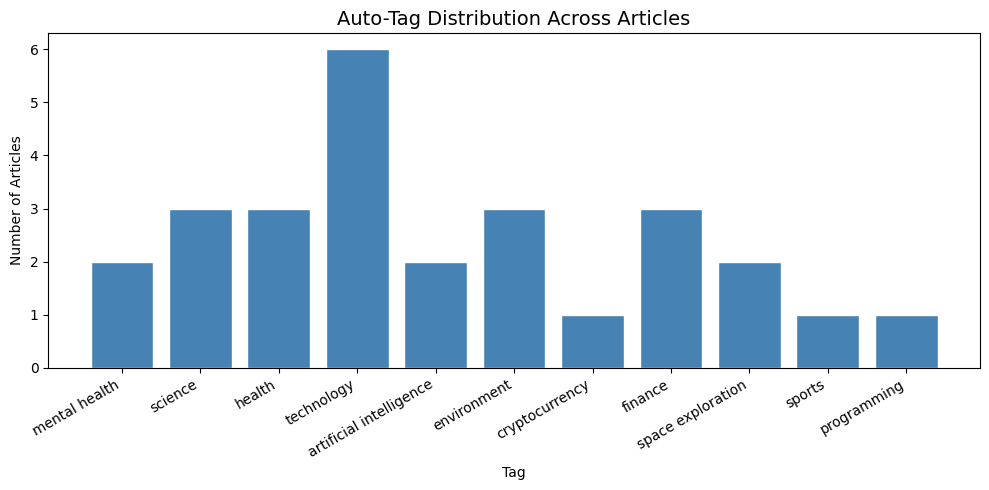

✅ Results saved to autotagged_articles.csv


In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# Count all assigned tags
all_tags = [tag for tags in df_results['tags'] for tag in tags]
tag_counts = Counter(all_tags)

# Plot
plt.figure(figsize=(10, 5))
plt.bar(tag_counts.keys(), tag_counts.values(), color='steelblue', edgecolor='white')
plt.title('Auto-Tag Distribution Across Articles', fontsize=14)
plt.xlabel('Tag')
plt.ylabel('Number of Articles')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Export results
df_results.to_csv('autotagged_articles.csv', index=False)
print("✅ Results saved to autotagged_articles.csv")